# Phase 1: Exploratory Data Analysis (EDA) & Data Quality Audit

**Module:** IT3091 - Machine Learning Project  
**Group ID:** 2026-AI-07  
**Lead Author:** E J M H D Bandara (IT24102278) — Data Understanding & EDA Lead  
**Co-Author / Pipeline Auditor:** H A Wickramathilaka (IT24100427) — Preprocessing Lead  

---
## Notebook Overview & Purpose
This notebook establishes the foundational empirical understanding of the **Telco Customer Churn** dataset. Each visualization directly informs our preprocessing transformations, feature engineering strategies, and model evaluation metrics. Every visual finding is tied to an actionable architectural decision in the Master Decision Log.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Visual formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.autolayout": True,
    "font.sans-serif": "Arial",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11
})

# Load Raw Dataset
data_path = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(data_path)
print(f"[SUCCESS] Raw Dataset Loaded: {df.shape[0]:,} records across {df.shape[1]} columns.")


[SUCCESS] Raw Dataset Loaded: 7,043 records across 21 columns.


---
## 1. Structural Schema Inspection & Anomaly Audit
We first examine the data types, non-null counts, and investigate anomalous string entries in numerical fields.

In [2]:
# Column Info & Null Value Summary
summary_df = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Unique Values": df.nunique()
})
summary_df


,Data Type,Non-Null Count,Null Count,Unique Values
customerID,str,7043,0,7043
gender,str,7043,0,2
SeniorCitizen,int64,7043,0,2
Partner,str,7043,0,2
Dependents,str,7043,0,2
tenure,int64,7043,0,73
PhoneService,str,7043,0,2
MultipleLines,str,7043,0,3
InternetService,str,7043,0,3
OnlineSecurity,str,7043,0,3


### TotalCharges Whitespace String Anomaly Audit
Notice that `TotalCharges` is inferred as an `object` (string) rather than `float64`. We isolate records containing blank whitespace (`" "`).

In [3]:
blank_mask = df["TotalCharges"] == " "
blank_records = df[blank_mask][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]
print(f"Total whitespace instances in TotalCharges: {len(blank_records)}")
blank_records


Total whitespace instances in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


> **Statistical Insight & Decision (DEC-03):**  
> All 11 instances with whitespace in `TotalCharges` have `tenure == 0`. These represent newly acquired subscribers who joined during the active evaluation window before receiving their first monthly invoice.  
> **Decision Chosen:** Impute `TotalCharges = 0.0` and cast to `float64`. Dropping these records would introduce survivor bias by eliminating newly enrolled subscribers.

In [4]:
# Impute TotalCharges for EDA exploration
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0.0").astype(float)
df["Churn_Numeric"] = df["Churn"].map({"Yes": 1, "No": 0})
print(f"[SUCCESS] TotalCharges successfully cast to float64. Missing values: {df['TotalCharges'].isnull().sum()}")


[SUCCESS] TotalCharges successfully cast to float64. Missing values: 0


---
## 2. Target Variable Distribution & Class Imbalance
We evaluate the base rate of customer churn to determine metric suitability.

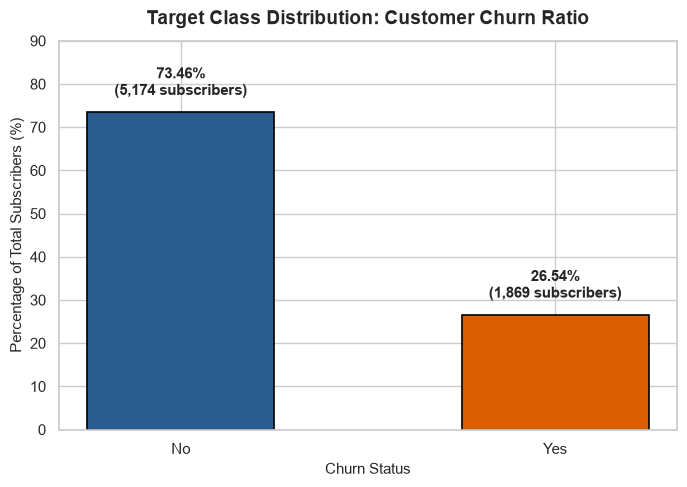

Majority Class (Retained): 73.46%
Minority Class (Churned):  26.54%
Class Imbalance Ratio:     2.77 : 1


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
churn_counts = df["Churn"].value_counts()
churn_pcts = df["Churn"].value_counts(normalize=True) * 100

colors = ["#2b5c8f", "#d95f02"]
bars = ax.bar(churn_pcts.index, churn_pcts.values, color=colors, width=0.5, edgecolor="black", linewidth=1.2)
ax.set_title("Target Class Distribution: Customer Churn Ratio", fontsize=14, weight="bold", pad=12)
ax.set_ylabel("Percentage of Total Subscribers (%)", fontsize=11)
ax.set_xlabel("Churn Status", fontsize=11)
ax.set_ylim(0, 90)

for i, bar in enumerate(bars):
    height = bar.get_height()
    count = churn_counts.iloc[i]
    ax.annotate(f"{height:.2f}%\n({count:,} subscribers)",
                (bar.get_x() + bar.get_width() / 2., height + 3),
                ha="center", va="bottom", fontsize=11, weight="bold")

plt.tight_layout()
plt.show()

print(f"Majority Class (Retained): {churn_pcts['No']:.2f}%")
print(f"Minority Class (Churned):  {churn_pcts['Yes']:.2f}%")
print(f"Class Imbalance Ratio:     {churn_pcts['No'] / churn_pcts['Yes']:.2f} : 1")


> **Modeling Implication:**  
> A naive classifier predicting "No Churn" for every customer achieves a deceptive **73.46% accuracy** while detecting exactly 0 churners.  
> Therefore, **Accuracy is rejected as the primary performance metric**. The model evaluation framework must optimize for **Recall, Precision-Recall AUC (PR-AUC), and ROC-AUC**.

---
## 3. Continuous Feature Distributions & "The Tenure Cliff"
We examine kernel density estimates (KDE) and boxplots for `tenure`, `MonthlyCharges`, and `TotalCharges` segmented by churn.

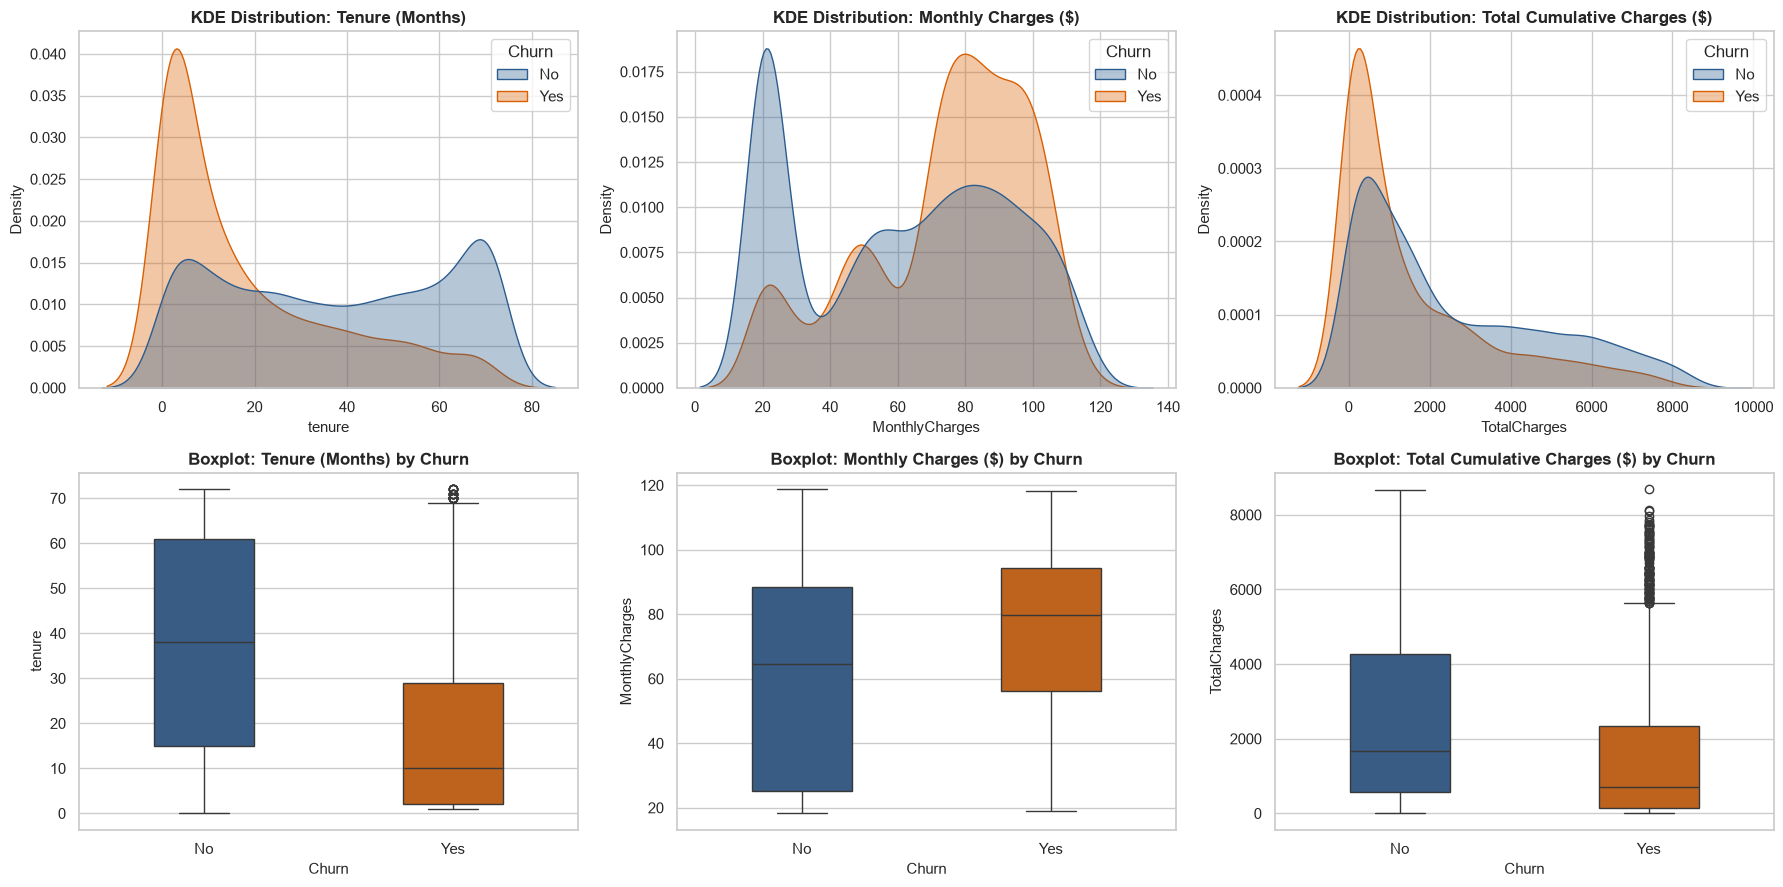

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
titles = ["Tenure (Months)", "Monthly Charges ($)", "Total Cumulative Charges ($)"]

for i, col in enumerate(num_cols):
    # Density KDE
    sns.kdeplot(data=df, x=col, hue="Churn", common_norm=False, fill=True,
                palette={"No": "#2b5c8f", "Yes": "#d95f02"}, alpha=0.35, ax=axes[0, i])
    axes[0, i].set_title(f"KDE Distribution: {titles[i]}", fontsize=12, weight="bold")
    axes[0, i].set_ylabel("Density")
    
    # Boxplot for Outlier & Quartile Diagnostics
    sns.boxplot(data=df, x="Churn", y=col, palette={"No": "#2b5c8f", "Yes": "#d95f02"}, ax=axes[1, i], width=0.4)
    axes[1, i].set_title(f"Boxplot: {titles[i]} by Churn", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()


> **Statistical Insights:**
> 1. **The Tenure Cliff:** The churn distribution exhibits a dramatic spike in months 1–6 (median churned tenure = 10 months vs. 38 months for retained). Subscribers who reach 24 months experience substantially higher retention rates.
> 2. **Price Sensitivity:** Churners display a significant concentration at higher monthly bills ($70 - $105/month, median ~$79.65 vs. $64.43 for retained). High recurring charges directly elevate churn risk.
> 3. **Outlier Assessment:** Continuous features show no unphysical or extreme outliers; the distributions reflect natural customer lifecycle boundaries.

---
## 4. Contract Terms & Service Tier Churn Rates
We analyze how contract structure and core network technology influence subscriber attrition.

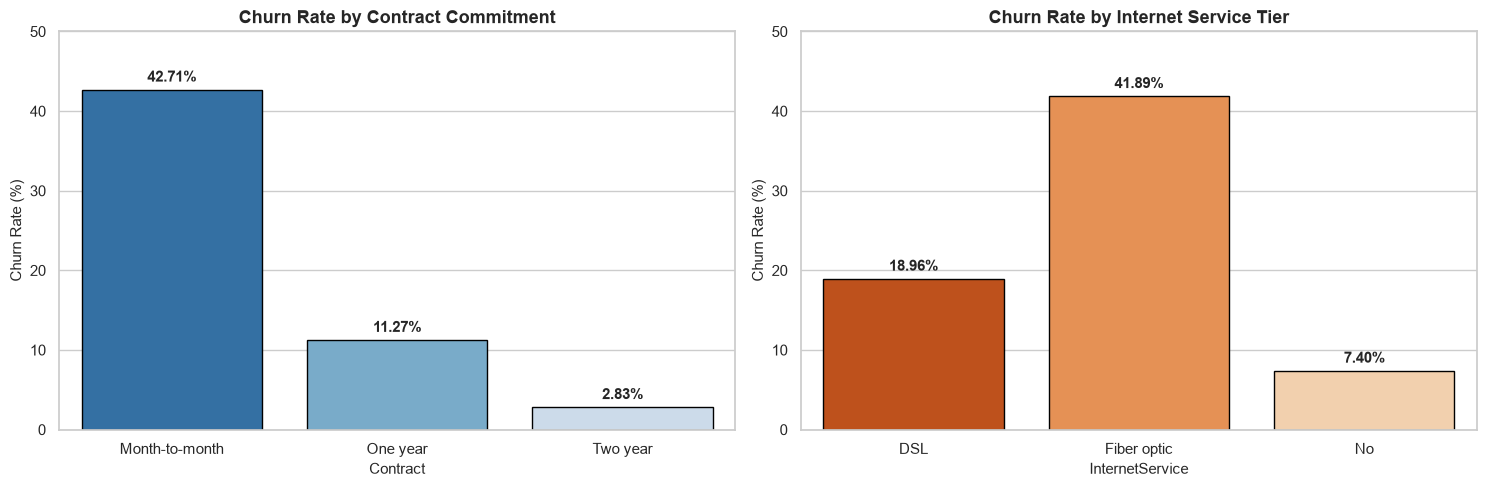

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Contract Commitment
contract_df = df.groupby("Contract")["Churn_Numeric"].agg(["count", "mean"]).reset_index()
contract_df["Churn_Rate_Pct"] = contract_df["mean"] * 100
sns.barplot(data=contract_df, x="Contract", y="Churn_Rate_Pct", ax=axes[0], palette="Blues_r", edgecolor="black")
axes[0].set_title("Churn Rate by Contract Commitment", fontsize=13, weight="bold")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 50)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                     ha="center", weight="bold", fontsize=11)

# Internet Service Tier
internet_df = df.groupby("InternetService")["Churn_Numeric"].agg(["count", "mean"]).reset_index()
internet_df["Churn_Rate_Pct"] = internet_df["mean"] * 100
sns.barplot(data=internet_df, x="InternetService", y="Churn_Rate_Pct", ax=axes[1], palette="Oranges_r", edgecolor="black")
axes[1].set_title("Churn Rate by Internet Service Tier", fontsize=13, weight="bold")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, 50)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                     ha="center", weight="bold", fontsize=11)

plt.tight_layout()
plt.show()


> **Key Business Findings:**
> - **Month-to-Month Exposure:** Over **42.71%** of month-to-month subscribers churn, compared to only **11.27%** for 1-year and **2.83%** for 2-year contracts. Lack of structural contractual commitment is the single strongest driver of churn.
> - **Fiber Optic Attrition:** Customers on `Fiber optic` internet churn at **41.89%**, more than double the churn rate of `DSL` (18.96%). This reveals either premium pricing friction ($70+ charges) or service reliability dissatisfaction.

---
## 5. Value-Added Service Adoption & "Product Stickiness"
We explore whether add-on services (`TechSupport`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`) serve as retention anchors.

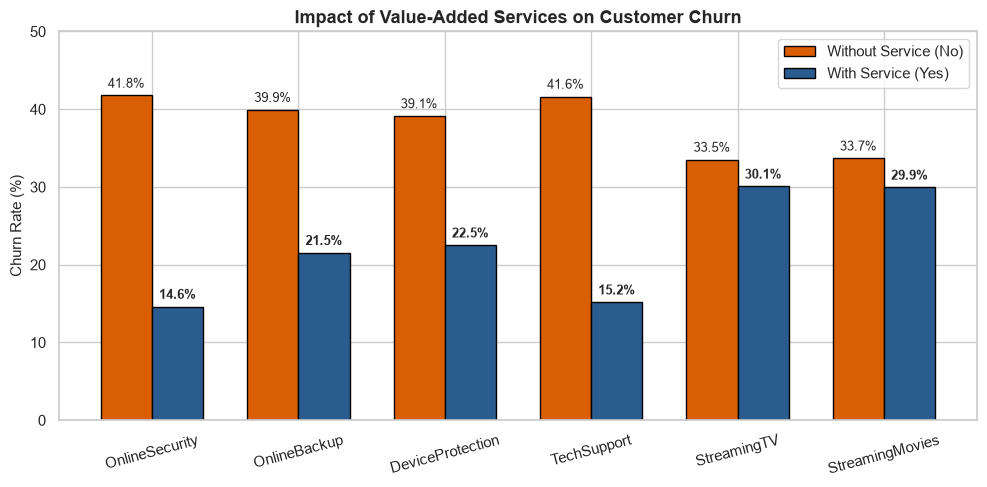

In [8]:
add_on_services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
add_on_rates = []

for s in add_on_services:
    grouped = df.groupby(s)["Churn_Numeric"].mean()
    if "Yes" in grouped and "No" in grouped:
        add_on_rates.append({
            "Service": s,
            "Churn_With_Service": grouped["Yes"] * 100,
            "Churn_Without_Service": grouped["No"] * 100
        })

add_on_df = pd.DataFrame(add_on_rates)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(add_on_df))
width = 0.35

rects1 = ax.bar(x - width/2, add_on_df["Churn_Without_Service"], width, label="Without Service (No)", color="#d95f02", edgecolor="black")
rects2 = ax.bar(x + width/2, add_on_df["Churn_With_Service"], width, label="With Service (Yes)", color="#2b5c8f", edgecolor="black")

ax.set_ylabel("Churn Rate (%)")
ax.set_title("Impact of Value-Added Services on Customer Churn", fontsize=13, weight="bold")
ax.set_xticks(x)
ax.set_xticklabels(add_on_df["Service"], rotation=15)
ax.legend()
ax.set_ylim(0, 50)

for r in rects1:
    ax.annotate(f"{r.get_height():.1f}%", (r.get_x() + r.get_width()/2., r.get_height() + 1), ha="center", fontsize=9)
for r in rects2:
    ax.annotate(f"{r.get_height():.1f}%", (r.get_x() + r.get_width()/2., r.get_height() + 1), ha="center", fontsize=9, weight="bold")

plt.tight_layout()
plt.show()


> **Feature Engineering Justification:**  
> Subscribers with `TechSupport` (15.16% churn vs. 41.64% without) and `OnlineSecurity` (14.61% churn vs. 41.77% without) exhibit nearly **3x lower churn rates**!  
> **Engineering Decision:** Create `ServiceBundleCount` to capture the cumulative stickiness of subscribed value-added services.

---
## 6. Payment Method Friction & Billing Dynamics
We examine the correlation between customer billing interaction and churn.

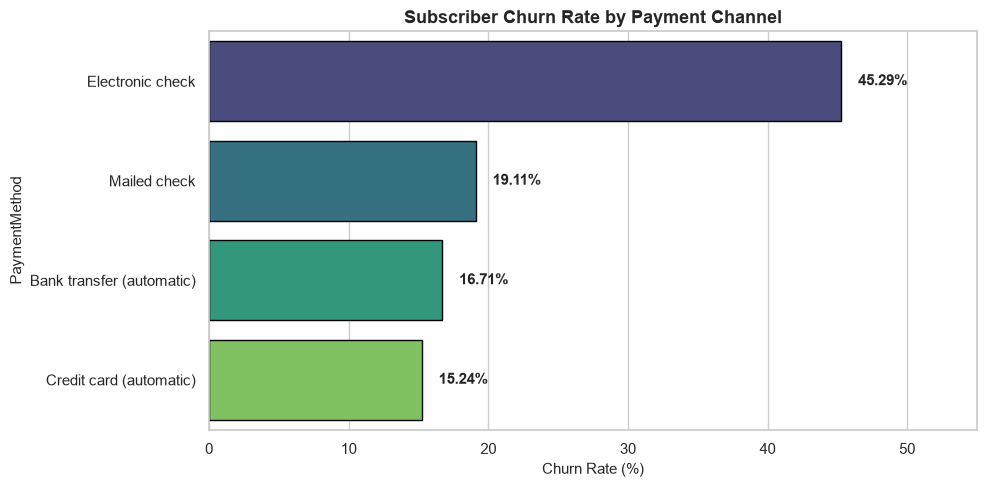

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
pm_df = df.groupby("PaymentMethod")["Churn_Numeric"].agg(["count", "mean"]).reset_index().sort_values("mean", ascending=False)
pm_df["Churn_Rate_Pct"] = pm_df["mean"] * 100

sns.barplot(data=pm_df, x="Churn_Rate_Pct", y="PaymentMethod", ax=ax, palette="viridis", edgecolor="black")
ax.set_title("Subscriber Churn Rate by Payment Channel", fontsize=13, weight="bold")
ax.set_xlabel("Churn Rate (%)")
ax.set_xlim(0, 55)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}%", (p.get_width() + 1.2, p.get_y() + p.get_height() / 2.),
                va="center", fontsize=11, weight="bold")

plt.tight_layout()
plt.show()


> **Insight:** `Electronic check` exhibits a staggering **45.29% churn rate**, while automated channels (`Credit card` at 15.24% and `Bank transfer` at 16.71%) maintain exceptionally stable accounts.  
> **Engineering Decision:** Create a binary feature `IsAutomaticPayment` to isolate automated vs. friction-prone manual payments.

---
## 7. Correlation Diagnostics & Multicollinearity Matrix
We generate the correlation matrix across numerical variables and the target to evaluate collinearity.

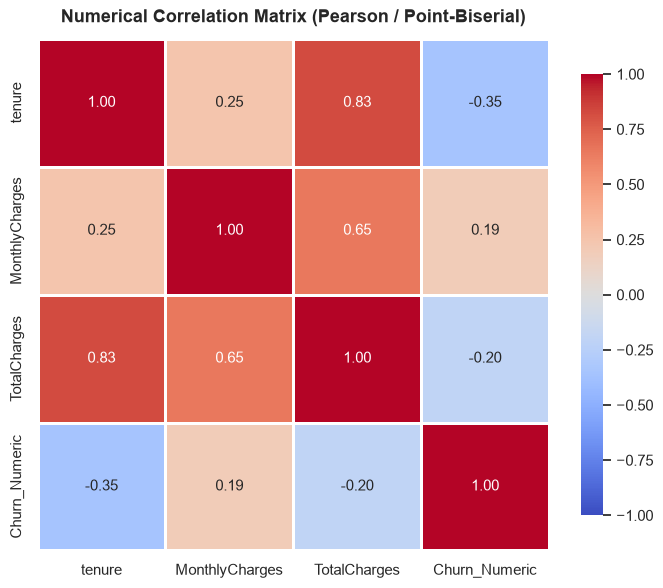

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn_Numeric"]].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.8}, linewidths=1, linecolor="white", ax=ax)
ax.set_title("Numerical Correlation Matrix (Pearson / Point-Biserial)", fontsize=13, weight="bold", pad=12)
plt.tight_layout()
plt.show()


> **Collinearity Diagnosis:**  
> - `tenure` and `TotalCharges` exhibit strong collinearity ($r = 0.83$), as expected since total charges accumulate over tenure.  
> - `tenure` correlates negatively with churn ($r = -0.35$), confirming that customer tenure serves as a protective loyalty factor.  
> - `MonthlyCharges` correlates positively with churn ($r = +0.19$), reflecting pricing pressure.  
> - Regularized models (Lasso / Ridge) and tree ensembles will naturally handle this multicollinearity.

---
## 8. Summary of EDA Findings & Preprocessing Specifications

| Empirical Finding | Visual Proof | Preprocessing Recommendation | Decision Reference |
| :--- | :--- | :--- | :--- |
| 11 blank spaces in `TotalCharges` | Section 1 Audit Table | Impute `0.0` (tenure = 0) and cast to `float64` | **DEC-03** |
| 73.5% / 26.5% Class Imbalance | Section 2 Distribution Bar | Reject raw accuracy; optimize PR-AUC, ROC-AUC, Recall | **DEC-02** |
| 0-12m Tenure Cliff | Section 3 KDE / Boxplots | Construct `TenureCohort` binned lifecycle feature | **DEC-04** |
| 3x Retention from Add-on Services | Section 5 Multi-bar Comparison | Construct `ServiceBundleCount` feature | **DEC-04** |
| Electronic Check (45.3% churn) | Section 6 Payment Channel Bar | Construct `IsAutomaticPayment` binary feature | **DEC-04** |
| $r = 0.83$ between `tenure` and `TotalCharges` | Section 7 Correlation Heatmap | Standardize continuous variables via `StandardScaler` | **DEC-05** |

**Notebook Author Sign-off:**  
E J M H D Bandara (IT24102278) — Data Understanding & EDA Lead